In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import statistics

In [20]:
telco_base_data = pd.read_csv("churn_modeling.csv")
# telco_base_data.head()

In [3]:
new_telco = telco_base_data[['Geography','Gender','Exited']]

In [4]:
new_telco.head()

,Geography,Gender,Exited
0,France,Female,NaN
1,Spain,Female,0.0
2,France,Female,1.0
3,France,Female,0.0
4,Spain,Female,0.0


## Univeriate analysis

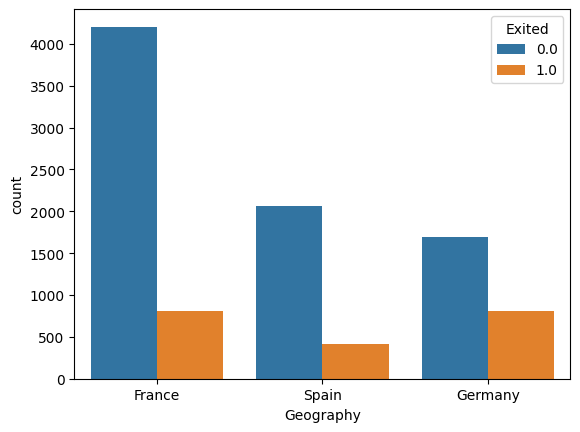

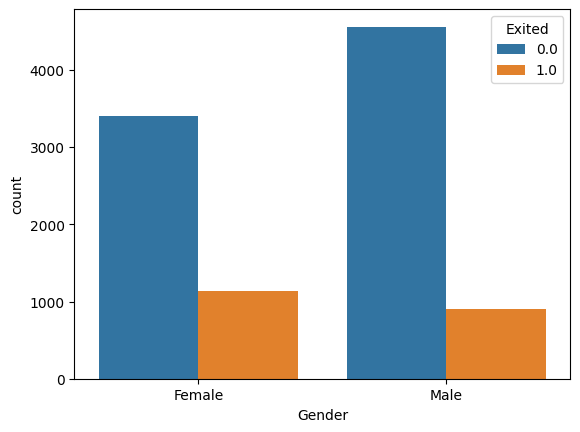

In [5]:
for i, predictor in enumerate(new_telco.drop(columns=['Exited'])):
    plt.figure()
    sns.countplot(data=new_telco, x=predictor, hue ='Exited')

## Bi-variate analysis

<Axes: xlabel='Gender', ylabel='Count'>

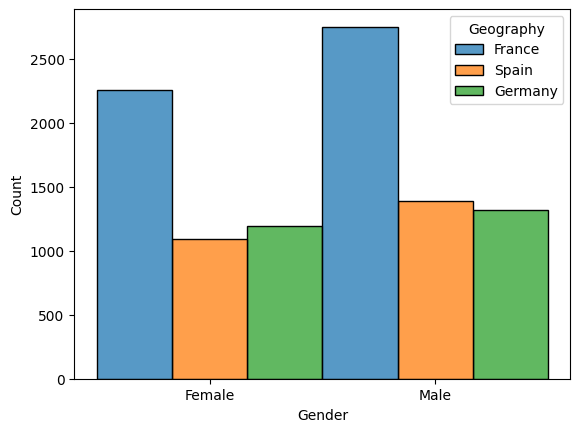

In [ ]:
sns.histplot(x='Gender', data=new_telco, stat="count", hue="Geography", multiple='dodge')
# hue parameter is used to color-code the histogram based on a categorical variables.
# stat decides what value is shown on the y-axis.
# multiple parameter (How multiple groups are displayed)
# multiple='dodge'-> Show histograms side-by-side (NOT overlapping, NOT stacked)

<Axes: xlabel='Gender', ylabel='Count'>

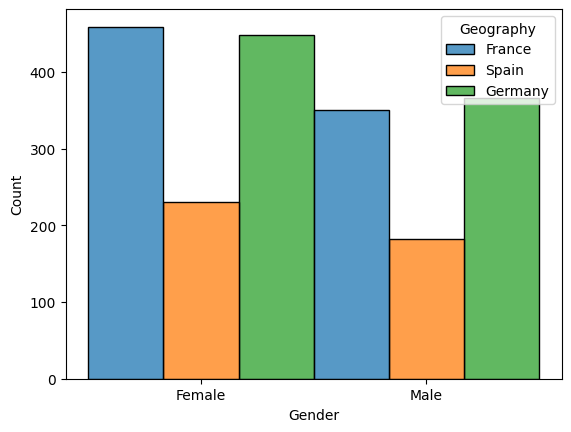

In [18]:
# getting info for churned customers.
telco_new_target1 = new_telco.loc[new_telco["Exited"] ==1]
sns.histplot(x='Gender', data=telco_new_target1, stat="count", hue="Geography", multiple='dodge')

## Numerical Analysis

In [23]:
# +1 : Positive correlation
# -1 : Negetive correlation
# 0  : No correlation
telco_base_data.corr(numeric_only=True)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006435,-0.009067,0.007246,-0.017319,0.012044,-0.005986,-0.016235
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014855,-0.012419,0.016972,-0.007839,0.001665,0.015273,-0.006094
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000853,0.006268,0.012238,-0.003265,0.025651,-0.001384,-0.027034
Age,0.000783,0.009497,-0.003965,1.000000,-0.010007,0.028308,-0.030680,0.002930,0.085472,-0.007202,0.285322
Tenure,-0.006435,-0.014855,0.000853,-0.010007,1.000000,-0.012211,0.013475,-0.013865,-0.028394,0.007787,-0.013798
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012211,1.000000,-0.304180,-0.012266,-0.010084,0.012801,0.118807
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013475,-0.304180,1.000000,-0.009115,0.009612,0.014207,-0.047651
HasCrCard,-0.017319,-0.007839,-0.003265,0.002930,-0.013865,-0.012266,-0.009115,1.000000,0.009698,-0.009935,-0.007267
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028394,-0.010084,0.009612,0.009698,1.000000,-0.011424,-0.156358
EstimatedSalary,-0.005986,0.015273,-0.001384,-0.007202,0.007787,0.012801,0.014207,-0.009935,-0.011424,1.000000,0.012095


<Axes: >

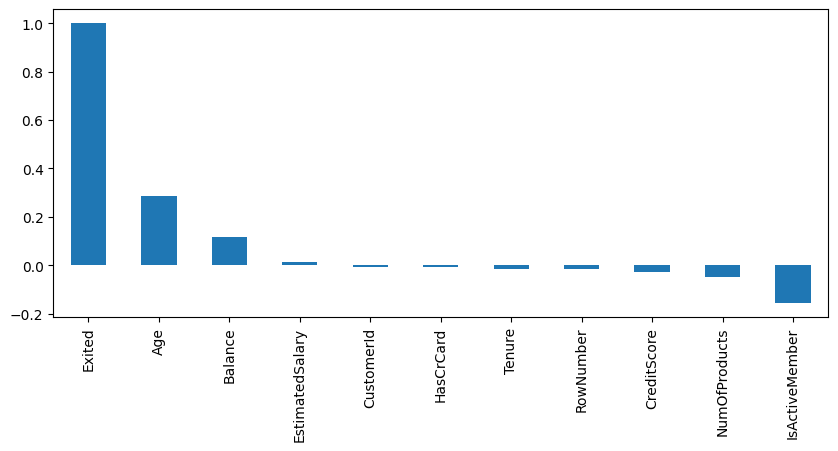

In [32]:
plt.figure(figsize=(10,4))
telco_base_data.corr(numeric_only=True)['Exited'].sort_values(ascending=False).plot(kind='bar')

<Axes: >

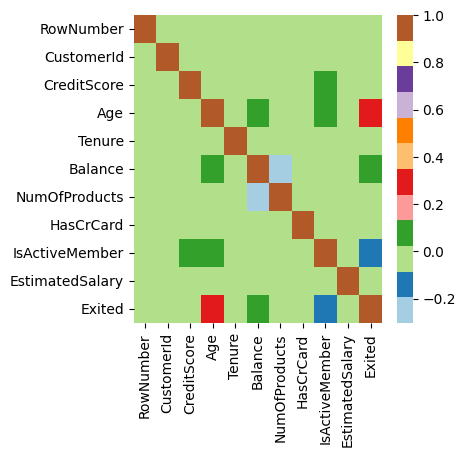

In [40]:
plt.figure(figsize=(4,4))
sns.heatmap(telco_base_data.corr(numeric_only=True), cmap="Paired")

In [49]:
telco_base_data['Age'].value_counts().sort_index(ascending=True).to_string()

'Age\n18     22\n19     27\n20     40\n21     53\n22     84\n23     99\n24    132\n25    154\n26    200\n27    209\n28    273\n29    348\n30    327\n31    404\n32    418\n33    442\n34    447\n35    474\n36    456\n37    478\n38    477\n39    423\n40    432\n41    366\n42    321\n43    297\n44    257\n45    229\n46    226\n47    175\n48    168\n49    147\n50    134\n51    119\n52    102\n53     74\n54     84\n55     82\n56     70\n57     75\n58     67\n59     62\n60     62\n61     53\n62     52\n63     40\n64     37\n65     18\n66     35\n67     37\n68     19\n69     22\n70     18\n71     27\n72     21\n73     13\n74     18\n75      9\n76     11\n77     10\n78      5\n79      4\n80      3\n81      4\n82      1\n83      1\n84      2\n85      1\n88      1\n92      2'

<Axes: xlabel='Age'>

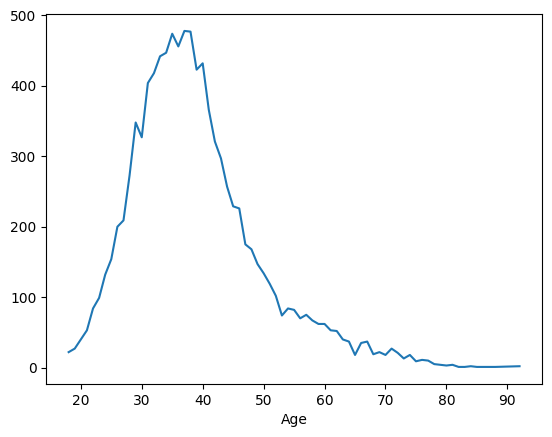

In [47]:
plt.Figure(figsize=(7,4))
telco_base_data['Age'].value_counts().sort_index(ascending=True).plot()

In [ ]:
# created new df for churned customers
telco_base_data_1 = telco_base_data[telco_base_data["Exited"] == 1]

<Axes: xlabel='Age'>

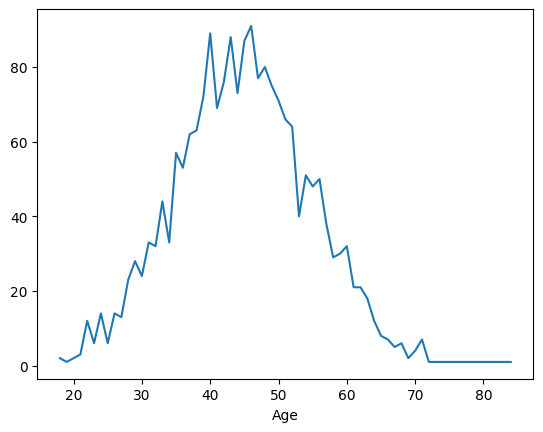

In [51]:
telco_base_data_1['Age'].value_counts().sort_index(ascending=True).plot()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17812\329900557.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_base_data.Age[(telco_base_data["Exited"]==0)],
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17812\329900557.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_base_data.Age[(telco_base_data["Exited"]==1)],


Text(0.5, 1.0, 'Age by churn')

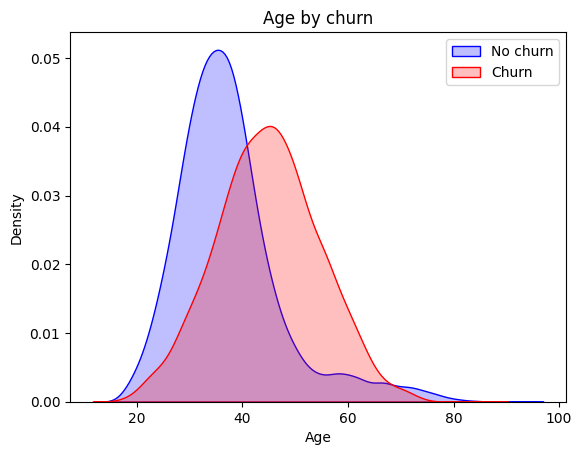

In [55]:
Tot = sns.kdeplot(telco_base_data.Age[(telco_base_data["Exited"]==0)],
                  color="Blue",shade=True)
Tot = sns.kdeplot(telco_base_data.Age[(telco_base_data["Exited"]==1)],
                  color="Red", shade=True)
Tot.legend(["No churn", "Churn"], loc='upper right')
Tot.set_ylabel("Density")
Tot.set_xlabel("Age")
Tot.set_title("Age by churn")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17812\1881989847.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_base_data.Balance[(telco_base_data["Exited"]==0)],
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17812\1881989847.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_base_data.Balance[(telco_base_data["Exited"]==1)],


Text(0.5, 1.0, 'Balance by churn')

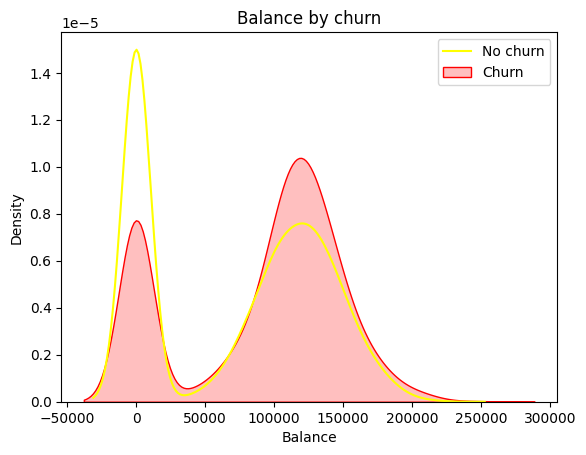

In [60]:
Tot = sns.kdeplot(telco_base_data.Balance[(telco_base_data["Exited"]==0)],
                  color="yellow",shade=False)
Tot = sns.kdeplot(telco_base_data.Balance[(telco_base_data["Exited"]==1)],
                  color="Red", shade=True)
Tot.legend(["No churn", "Churn"], loc='upper right')
Tot.set_ylabel("Density")
Tot.set_xlabel("Balance")
Tot.set_title("Balance by churn")